## IMPORTAR BIBLIOTECAS

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

## CARREGAR DADOS

In [4]:
df = pd.read_csv("dados_tratados.csv")

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,conta_diaria
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


## LIMPEZA E TRATAMENTO DO TARGET

In [5]:
df = df.dropna(subset=["Churn"])
df["Churn"] = df["Churn"].astype(int)
df = df.drop(columns=["customerID"], errors="ignore")

## FEATURE ENGINEERING

In [7]:
df["avg_monthly_spend"] = df["account.Charges.Total"] / (df["customer.tenure"] + 1)
df["cliente_novo"] = (df["customer.tenure"] < 12).astype(int)

## ANÁLISE DE DISTRIBUIÇÃO DO CHURN

Churn
0    5163
1    1869
Name: count, dtype: int64
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


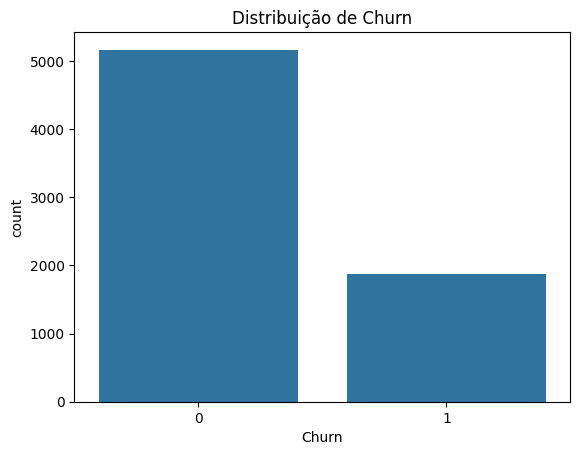

In [8]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True))

sns.countplot(x="Churn", data=df)
plt.title("Distribuição de Churn")
plt.show()

## CORRELAÇÃO DAS VARIÁVEIS COM O TARGET

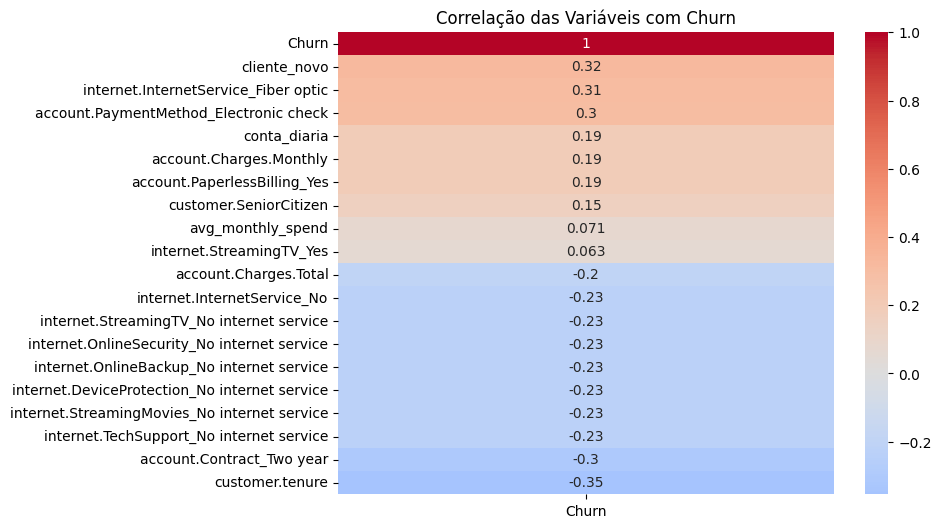

Churn                                            1.000000
cliente_novo                                     0.319816
internet.InternetService_Fiber optic             0.307463
account.PaymentMethod_Electronic check           0.301455
conta_diaria                                     0.192858
account.Charges.Monthly                          0.192858
account.PaperlessBilling_Yes                     0.191454
customer.SeniorCitizen                           0.150541
avg_monthly_spend                                0.070992
internet.StreamingTV_Yes                         0.063254
account.Charges.Total                           -0.199484
internet.InternetService_No                     -0.227578
internet.StreamingTV_No internet service        -0.227578
internet.OnlineSecurity_No internet service     -0.227578
internet.OnlineBackup_No internet service       -0.227578
internet.DeviceProtection_No internet service   -0.227578
internet.StreamingMovies_No internet service    -0.227578
internet.TechS

In [10]:
df_corr = df.copy()

# Encoding apenas para análise
df_corr = pd.get_dummies(df_corr, drop_first=True)

# Correlação com target
corr_target = df_corr.corr()["Churn"].sort_values(ascending=False)

# Top positivas e negativas
top_corr = pd.concat([corr_target.head(10), corr_target.tail(10)])

plt.figure(figsize=(8,6))
sns.heatmap(top_corr.to_frame(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlação das Variáveis com Churn")
plt.show()

print(top_corr)

## CORRELAÇÃO DAS VARIÁVEIS COM O CHURN

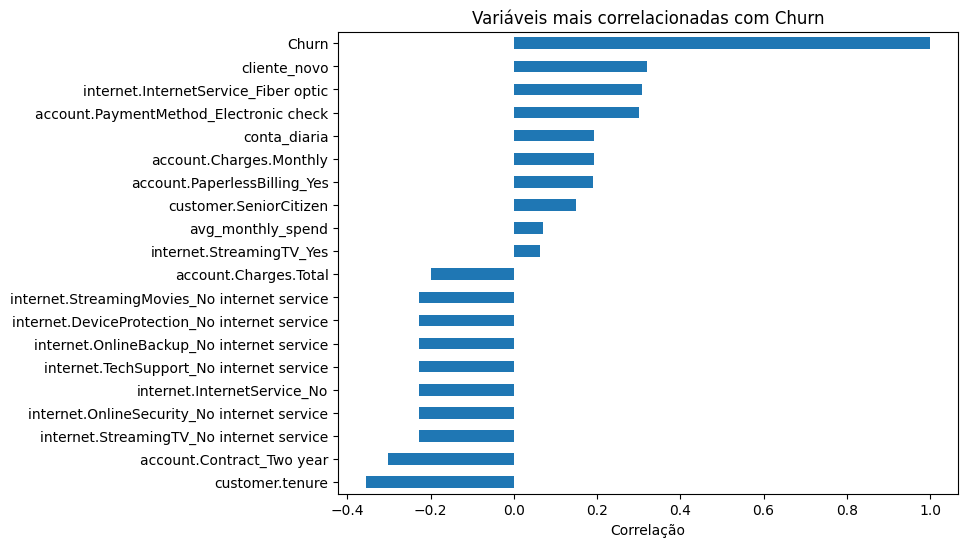

In [12]:
top_corr.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Variáveis mais correlacionadas com Churn")
plt.xlabel("Correlação")
plt.show()

## ANÁLISES DIRECIONADAS

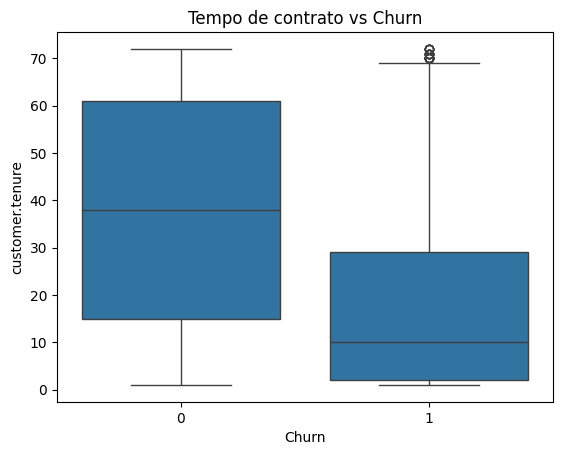

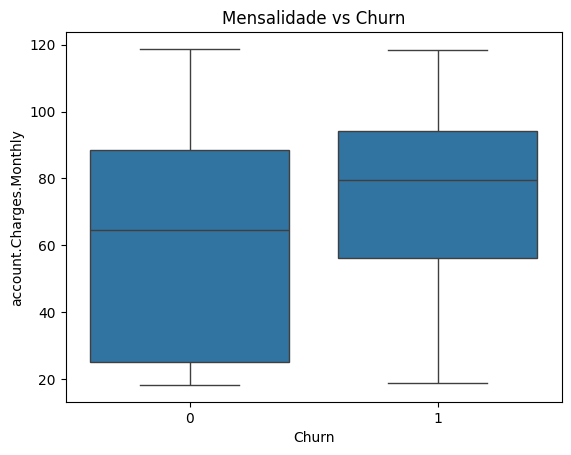

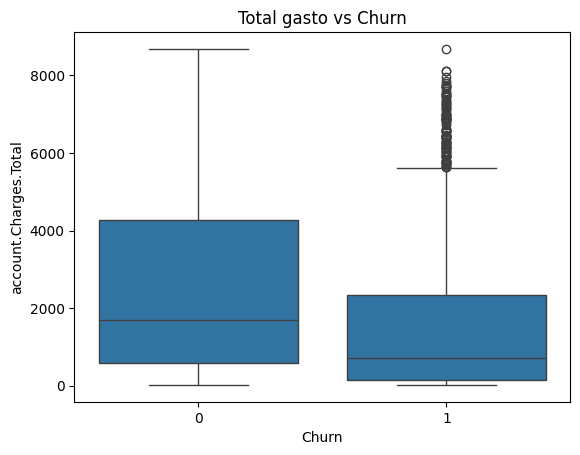

In [13]:
# Tenure vs Churn
sns.boxplot(x="Churn", y="customer.tenure", data=df)
plt.title("Tempo de contrato vs Churn")
plt.show()

# Monthly Charges vs Churn
sns.boxplot(x="Churn", y="account.Charges.Monthly", data=df)
plt.title("Mensalidade vs Churn")
plt.show()

# Total Charges vs Churn
sns.boxplot(x="Churn", y="account.Charges.Total", data=df)
plt.title("Total gasto vs Churn")
plt.show()

## SEPARAÇÃO DOS DADOS | TREINO/TESTE

In [14]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

## PREPARAÇÃO DAS VARIÁVEIS PARA MODELAGEM

In [15]:
categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

## PIPELINE DE PRÉ-PROCESSAMENTO

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(
            drop="if_binary",
            handle_unknown="ignore",
            sparse_output=False
        ), categorical_cols)
    ]
)

## DEFINIÇÕES DOS MODELOS

In [17]:
pipe_log = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

pipe_rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced",
        random_state=42
    ))
])

pipe_gb = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingClassifier())
])

## TREINAMENTO DOS MODELOS

In [18]:
pipe_log.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
pipe_gb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## AVALIAÇÕES DOS MODELOS


=== Logistic ===
Accuracy: 0.7507109004739336
Precision: 0.5203725261932479
Recall: 0.7967914438502673
F1: 0.6295774647887324
ROC-AUC: 0.8479347839846074
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1549
           1       0.52      0.80      0.63       561

    accuracy                           0.75      2110
   macro avg       0.71      0.77      0.72      2110
weighted avg       0.81      0.75      0.76      2110



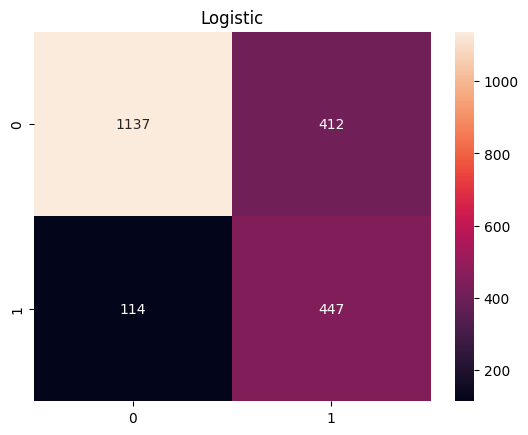


=== RandomForest ===
Accuracy: 0.7677725118483413
Precision: 0.550354609929078
Recall: 0.6916221033868093
F1: 0.6129541864139021
ROC-AUC: 0.8395359434929557
              precision    recall  f1-score   support

           0       0.88      0.80      0.83      1549
           1       0.55      0.69      0.61       561

    accuracy                           0.77      2110
   macro avg       0.71      0.74      0.72      2110
weighted avg       0.79      0.77      0.78      2110



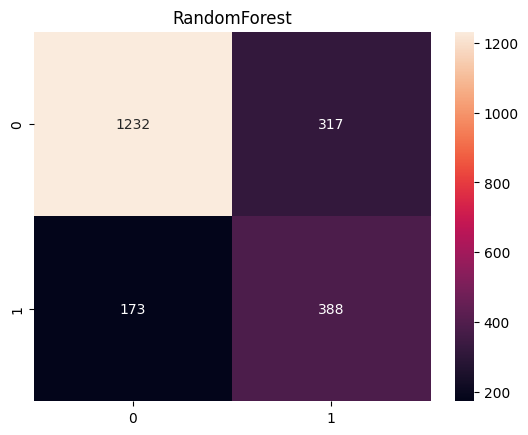


=== GradientBoosting ===
Accuracy: 0.8028436018957346
Precision: 0.6629213483146067
Recall: 0.5258467023172906
F1: 0.5864811133200796
ROC-AUC: 0.8470797674078728
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1549
           1       0.66      0.53      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.71      0.73      2110
weighted avg       0.79      0.80      0.80      2110



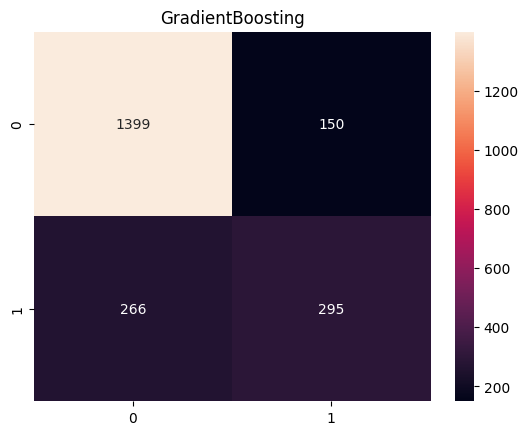

In [19]:
def avaliar(nome, model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n=== {nome} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(nome)
    plt.show()

avaliar("Logistic", pipe_log)
avaliar("RandomForest", pipe_rf)
avaliar("GradientBoosting", pipe_gb)

## VALIDAÇÃO CRUZADA

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nome, modelo in [
    ("Logistic", pipe_log),
    ("RandomForest", pipe_rf),
    ("GradientBoosting", pipe_gb)
]:
    scores = cross_val_score(modelo, X, y, cv=cv, scoring="f1")
    print(f"{nome} F1 médio: {scores.mean():.4f}")

Logistic F1 médio: 0.6318
RandomForest F1 médio: 0.6284
GradientBoosting F1 médio: 0.5930


## VARIÁVEIS MAIS IMPORTANTES

rf_model = pipe_rf.named_steps["model"]

# pegar nomes das features após encoding
ohe = pipe_rf.named_steps["preprocess"].named_transformers_["cat"]
encoded_cols = ohe.get_feature_names_out(categorical_cols)

all_features = list(numeric_cols) + list(encoded_cols)

importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False)

feat_imp.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Features mais importantes")
plt.show()

In [22]:
print("""
CONCLUSÃO ESTRATÉGICA

1. Clientes novos apresentam maior taxa de churn
   → Estratégia: foco em retenção nos primeiros meses

2. Clientes com contratos mensais têm maior risco
   → Estratégia: incentivar contratos anuais

3. Clientes com maior valor mensal tendem a cancelar mais
   → Estratégia: revisar percepção de valor

4. Internet fibra óptica apresenta maior evasão
   → Estratégia: investigar qualidade do serviço

5. Pagamento via electronic check está associado ao churn
   → Estratégia: incentivar métodos automáticos

MODELO RECOMENDADO:
- Logistic Regression → melhor recall (captura churn)
- Ideal para negócio → evitar perder cliente

RECOMENDAÇÃO FINAL:
Usar modelo com maior recall para ações preventivas
e reduzir churn com campanhas direcionadas.
""")


CONCLUSÃO ESTRATÉGICA

1. Clientes novos apresentam maior taxa de churn
   → Estratégia: foco em retenção nos primeiros meses

2. Clientes com contratos mensais têm maior risco
   → Estratégia: incentivar contratos anuais

3. Clientes com maior valor mensal tendem a cancelar mais
   → Estratégia: revisar percepção de valor

4. Internet fibra óptica apresenta maior evasão
   → Estratégia: investigar qualidade do serviço

5. Pagamento via electronic check está associado ao churn
   → Estratégia: incentivar métodos automáticos

MODELO RECOMENDADO:
- Logistic Regression → melhor recall (captura churn)
- Ideal para negócio → evitar perder cliente

RECOMENDAÇÃO FINAL:
Usar modelo com maior recall para ações preventivas
e reduzir churn com campanhas direcionadas.



In [25]:
from datetime import datetime

def gerar_relatorio():
    
    def get_metrics(model):
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
        return {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "ROC_AUC": roc_auc_score(y_test, y_prob)
        }

    resultados = {
        "Logistic Regression": get_metrics(pipe_log),
        "Random Forest": get_metrics(pipe_rf),
        "Gradient Boosting": get_metrics(pipe_gb)
    }

    df_resultados = pd.DataFrame(resultados).T

    melhor_modelo = df_resultados["F1"].idxmax()

    print("\n" + "="*60)
    print("RELATÓRIO FINAL - TELECOM X (CHURN)")
    print("="*60)

    print("\n DESEMPENHO DOS MODELOS")
    print(df_resultados.round(4))

    print("\n MELHOR MODELO (baseado em F1-score):")
    print(f"→ {melhor_modelo}")

    print("\n INTERPRETAÇÃO DOS RESULTADOS:")
    print("""
- Modelos foram avaliados com foco em equilíbrio entre precisão e recall
- O F1-score foi utilizado como métrica principal devido ao desbalanceamento
- O modelo escolhido apresenta melhor capacidade de identificar churn sem exagerar em falsos positivos
    """)

    print("\n PRINCIPAIS FATORES DE CHURN:")
    print("""
- Clientes novos apresentam maior evasão
- Contratos mensais aumentam risco
- Internet fibra está associada a maior churn
- Clientes com maior mensalidade tendem a cancelar mais
- Pagamento via electronic check apresenta maior evasão
    """)

    print("\n RECOMENDAÇÕES ESTRATÉGICAS:")
    print("""
- Criar campanhas de retenção para clientes nos primeiros 12 meses
- Incentivar contratos de longo prazo
- Revisar percepção de valor para clientes com mensalidade alta
- Melhorar qualidade ou atendimento para clientes fibra
- Incentivar métodos de pagamento automáticos
    """)

    print("\n PRÓXIMOS PASSOS:")
    print("""
- Implementar modelo em produção
- Criar dashboard para monitoramento de churn
- Testar modelos mais avançados (XGBoost)
- Aplicar técnicas de balanceamento (SMOTE)
    """)

    print("\n" + "="*60)


# Executar
gerar_relatorio()


RELATÓRIO FINAL - TELECOM X (CHURN)

 DESEMPENHO DOS MODELOS
                     Accuracy  Precision  Recall      F1  ROC_AUC
Logistic Regression    0.7507     0.5204  0.7968  0.6296   0.8479
Random Forest          0.7678     0.5504  0.6916  0.6130   0.8395
Gradient Boosting      0.8028     0.6629  0.5258  0.5865   0.8471

 MELHOR MODELO (baseado em F1-score):
→ Logistic Regression

 INTERPRETAÇÃO DOS RESULTADOS:

- Modelos foram avaliados com foco em equilíbrio entre precisão e recall
- O F1-score foi utilizado como métrica principal devido ao desbalanceamento
- O modelo escolhido apresenta melhor capacidade de identificar churn sem exagerar em falsos positivos
    

 PRINCIPAIS FATORES DE CHURN:

- Clientes novos apresentam maior evasão
- Contratos mensais aumentam risco
- Internet fibra está associada a maior churn
- Clientes com maior mensalidade tendem a cancelar mais
- Pagamento via electronic check apresenta maior evasão
    

 RECOMENDAÇÕES ESTRATÉGICAS:

- Criar campanhas de